# Surgical biomedical concept UMAP, PubMedBERT embeddings up to 2025

This notebook creates a paper-style 2D concept map from the surgical biomedical concept embeddings.

Pipeline:

1. Load averaged PubMedBERT concept embeddings up to 2025.
2. Run UMAP to reduce 768-dimensional concept embeddings to 2D.
3. Join UMAP coordinates with the graph lookup table.
4. Save a reusable CSV.
5. Plot a static PNG-style map.
6. Create interactive Plotly maps, including an anchor-concept highlight map.

The input embedding file is:

```text
data/model/surgery/semantic/pubmedbert_2025.current.pkl.gz
```

The output files are written to:

```text
visualization/umap/
```

In [1]:
from pathlib import Path
import gzip
import pickle
import random

import numpy as np
import pandas as pd

def find_project_root(start: Path | None = None) -> Path:
    """Find the repo root even if Jupyter starts inside notebooks/."""
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "data").exists() and (candidate / "materials_concepts").exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find project root from {start}. "
        "Start Jupyter inside the repo or set PROJECT_ROOT manually."
    )

PROJECT_ROOT = find_project_root()

EMBEDDINGS_PATH = PROJECT_ROOT / "data/model/surgery/semantic/pubmedbert_2025.current.pkl.gz"
LOOKUP_PATH = PROJECT_ROOT / "data/table/lookup/surgery.lookup.csv"
ANCHOR_PATH = PROJECT_ROOT / "data/model/surgery/future/anchor_concepts.txt"
OUTPUT_DIR = PROJECT_ROOT / "visualization/umap"

UMAP_PICKLE_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap2d.pkl.gz"
UMAP_CSV_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap2d.csv"
STATIC_PNG_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap.png"
INTERACTIVE_HTML_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap.html"
ANCHOR_HTML_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap_anchors.html"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

for p in [EMBEDDINGS_PATH, LOOKUP_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

print("project root:", PROJECT_ROOT)
print("embeddings:", EMBEDDINGS_PATH, EMBEDDINGS_PATH.stat().st_size / 1024**2, "MB")
print("lookup:", LOOKUP_PATH)
print("output dir:", OUTPUT_DIR)

project root: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml
embeddings: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/data/model/surgery/semantic/pubmedbert_2025.current.pkl.gz 226.3191614151001 MB
lookup: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/data/table/lookup/surgery.lookup.csv
output dir: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap


## Install/import dependencies

If this cell fails because `umap` is missing, install it in the current environment:

```bash
python -m pip install umap-learn
```

For interactive HTML plots, `plotly` is needed. Static plots use `matplotlib`.

In [2]:
import matplotlib.pyplot as plt
import plotly.graph_objects as go

try:
    import umap
except ImportError as exc:
    raise ImportError(
        "Missing dependency: umap-learn. Install it with: python -m pip install umap-learn"
    ) from exc

print("dependencies imported")

/opt/anaconda3/envs/materials-concepts-embeddings/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


dependencies imported


## Load averaged PubMedBERT concept embeddings

The averaged embedding file is expected to be a dictionary:

```text
concept_id -> 768-dimensional vector
```

In this repo these values may be `torch.Tensor`, NumPy arrays, or array-like objects, so the loader below converts everything to a NumPy matrix safely.

In [3]:
def load_gzip_pickle(path: Path):
    with gzip.open(path, "rb") as f:
        return pickle.load(f)

embeddings = load_gzip_pickle(EMBEDDINGS_PATH)
lookup = pd.read_csv(LOOKUP_PATH)

print("embedding entries:", len(embeddings))
print("lookup rows:", len(lookup))
print("lookup columns:", list(lookup.columns))

first_key = next(iter(embeddings))
first_value = embeddings[first_key]
print("first key:", first_key, type(first_key))
print("first value type:", type(first_value), "shape:", getattr(first_value, "shape", None))

embedding entries: 82283
lookup rows: 82283
lookup columns: ['id', 'concept', 'count', 'in_graph']
first key: 1242 <class 'int'>
first value type: <class 'torch.Tensor'> shape: torch.Size([768])


In [4]:
def vector_to_numpy(value):
    """Convert torch tensors / NumPy arrays / array-like vectors to float32 NumPy arrays."""
    if hasattr(value, "detach"):
        value = value.detach().cpu().numpy()
    else:
        value = np.asarray(value)
    return value.astype(np.float32, copy=False)

concept_ids = []
vectors = []

for concept_id, vector in embeddings.items():
    arr = vector_to_numpy(vector)
    if arr.ndim != 1:
        raise ValueError(f"Expected a 1D vector for concept_id={concept_id}, got shape={arr.shape}")
    concept_ids.append(int(concept_id))
    vectors.append(arr)

X = np.vstack(vectors).astype(np.float32, copy=False)
concept_ids = np.asarray(concept_ids, dtype=np.int64)

print("X shape:", X.shape)
print("concept_id range:", int(concept_ids.min()), int(concept_ids.max()))
print("finite values:", bool(np.isfinite(X).all()))

X shape: (82283, 768)
concept_id range: 0 82282
finite values: True


## Run UMAP

These settings are a reasonable default for a global concept map:

- `n_neighbors=30`: balances local clusters and global structure.
- `min_dist=0.05`: allows visible clusters.
- `metric="cosine"`: usually appropriate for BERT-style semantic embeddings.
- `random_state=42`: makes the layout reproducible.

If you want a more separated/clumpy map, lower `min_dist`. If you want smoother global organization, increase `n_neighbors`.

In [5]:
N_NEIGHBORS = 15
MIN_DIST = 0.02
METRIC = "cosine"
RANDOM_STATE = 42

reducer = umap.UMAP(
    n_components=2,
    n_neighbors=N_NEIGHBORS,
    min_dist=MIN_DIST,
    metric=METRIC,
    random_state=RANDOM_STATE,
    verbose=True,
)

coords = reducer.fit_transform(X)
coords = coords.astype(np.float32, copy=False)

print("coords shape:", coords.shape)
print("x range:", float(coords[:, 0].min()), float(coords[:, 0].max()))
print("y range:", float(coords[:, 1].min()), float(coords[:, 1].max()))

UMAP(angular_rp_forest=True, metric='cosine', min_dist=0.02, n_jobs=1, random_state=42, verbose=True)
Mon Jun 29 18:46:27 2026 Construct fuzzy simplicial set
Mon Jun 29 18:46:27 2026 Finding Nearest Neighbors


/opt/anaconda3/envs/materials-concepts-embeddings/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


Mon Jun 29 18:46:27 2026 Building RP forest with 19 trees
Mon Jun 29 18:46:35 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	Stopping threshold met -- exiting after 5 iterations
Mon Jun 29 18:46:50 2026 Finished Nearest Neighbor Search
Mon Jun 29 18:46:52 2026 Construct embedding


Epochs completed:   2%| ▏          3/200 [00:00]

	completed  0  /  200 epochs


...

	completed  160  /  200 epochs


Epochs completed:  91%| █████████  182/200 [00:30]

	completed  180  /  200 epochs


Epochs completed: 100%| ██████████ 200/200 [00:33]


Mon Jun 29 18:47:35 2026 Finished embedding
coords shape: (82283, 2)
x range: -10.651031494140625 11.901006698608398
y range: -1.748839020729065 21.708837509155273


## Save UMAP coordinates as pickle and CSV

The pickle keeps the original repo-style dictionary format:

```text
concept_id -> [umap_x, umap_y]
```

The CSV is easier to inspect and plot.

In [6]:
umap_dict = {int(concept_id): coords[i] for i, concept_id in enumerate(concept_ids)}

with gzip.open(UMAP_PICKLE_PATH, "wb") as f:
    pickle.dump(umap_dict, f)

coords_df = pd.DataFrame({
    "id": concept_ids.astype(int),
    "umap_x": coords[:, 0],
    "umap_y": coords[:, 1],
})

umap_df = coords_df.merge(lookup, on="id", how="left")
umap_df = umap_df.sort_values("count", ascending=False)
umap_df.to_csv(UMAP_CSV_PATH, index=False)

print("wrote:", UMAP_PICKLE_PATH)
print("wrote:", UMAP_CSV_PATH)
print("rows:", len(umap_df))
umap_df.head(10)

wrote: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap/surgery_pubmedbert_2025_umap2d.pkl.gz
wrote: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap/surgery_pubmedbert_2025_umap2d.csv
rows: 82283


,id,umap_x,umap_y,concept,count,in_graph
35,57561,-0.758688,9.147021,postoperative complications,13167,True
108,30287,3.792330,8.141268,hepatocellular carcinoma,7482,True
420,19611,2.715433,1.991625,disease-free survival,6996,True
149,6866,0.085817,5.764031,bariatric surgery,6600,True
296,39178,-4.718668,8.618743,length of stay,6267,True
79,14399,3.365254,7.576075,colorectal cancer,5321,True
465,8700,1.181344,12.674403,body mass index,5195,True
4030,53952,-3.222836,7.079197,percutaneous coronary intervention,5194,True
692,72884,-0.345892,8.423580,surgical site infection,4459,True
162,63562,2.712113,1.993431,recurrence-free survival,4155,True


## Optional: inspect concepts near a selected concept

Use this to sanity-check whether the UMAP neighborhood around a concept is meaningful.

In [7]:
def nearest_umap_neighbors(concept: str, k: int = 20):
    concept = concept.strip().lower()
    rows = umap_df[umap_df["concept"] == concept]
    if rows.empty:
        raise ValueError(f"Concept not found: {concept}")
    x, y = rows.iloc[0][["umap_x", "umap_y"]].astype(float)
    tmp = umap_df.copy()
    tmp["umap_distance"] = np.sqrt((tmp["umap_x"] - x) ** 2 + (tmp["umap_y"] - y) ** 2)
    return tmp.sort_values("umap_distance").head(k + 1)[["concept", "count", "umap_distance"]]

nearest_umap_neighbors("anastomotic leak", k=20)

,concept,count,umap_distance
60,anastomotic leak,2599,0.000000
30526,internal opening,3,0.012187
55,anastomotic leakage,1955,0.018206
48774,airway injuries,4,0.018207
777,clinical anastomotic leakage,11,0.026732
21727,airway edema,3,0.027418
30735,anastomotic breakdown,4,0.036330
24753,major anastomotic leak,3,0.038459
38037,intraoperative anastomotic leakage,3,0.039126
4167,cervical anastomotic leak,10,0.040352


## Paper-style UMAP: density background + highest-degree concept per tile

This reproduces the visual logic of the paper's concept map:

- all retained graph concepts are plotted as background points;
- a yellow/purple density background is computed from the 2D UMAP coordinates using a Gaussian-smoothed 2D density estimate;
- the highest-degree concept in each square tile of side length `2` is highlighted and annotated.

Here, "degree" is the 2025 concept-graph degree: the number of unique directly connected concepts up to the end of 2025. This is different from `count`, which is the number of times a concept label appeared in the corpus.

In [8]:
from datetime import date
from materials_concepts.utils.constants import ORIGIN_DATE

GRAPH_PATH = PROJECT_ROOT / "data/graph/surgery.edges.pkl"
PAPER_STYLE_PNG_PATH = OUTPUT_DIR / "umap.png"
PAPER_STYLE_LANDMARKS_CSV_PATH = OUTPUT_DIR / "surgery_pubmedbert_2025_umap_tile_landmarks.csv"

if not GRAPH_PATH.exists():
    raise FileNotFoundError(GRAPH_PATH)

with open(GRAPH_PATH, "rb") as f:
    graph = pickle.load(f)

edges = np.asarray(graph["edges"], dtype=np.int64)
cutoff_days = (date(2026, 1, 1) - ORIGIN_DATE).days
edges_2025 = edges[edges[:, 2] < cutoff_days]

# Degree should be based on unique graph links, not repeated temporal edge rows.
pairs_2025 = np.sort(edges_2025[:, :2], axis=1)
unique_pairs_2025 = np.unique(pairs_2025, axis=0)
num_nodes = int(graph["num_of_vertices"])
node_degree_2025 = np.bincount(unique_pairs_2025.ravel(), minlength=num_nodes)

degree_df = pd.DataFrame({
    "id": np.arange(num_nodes, dtype=int),
    "graph_degree_2025": node_degree_2025.astype(int),
})

umap_df = umap_df.drop(columns=["graph_degree_2025"], errors="ignore").merge(
    degree_df,
    on="id",
    how="left",
)
umap_df["graph_degree_2025"] = umap_df["graph_degree_2025"].fillna(0).astype(int)

print("unique graph pairs through 2025:", len(unique_pairs_2025))
print("degree min/median/max:", int(umap_df["graph_degree_2025"].min()), float(umap_df["graph_degree_2025"].median()), int(umap_df["graph_degree_2025"].max()))
umap_df.sort_values("graph_degree_2025", ascending=False).head(10)[["id", "concept", "count", "graph_degree_2025", "umap_x", "umap_y"]]

unique graph pairs through 2025: 2456606
degree min/median/max: 2 21.0 17945


,id,concept,count,graph_degree_2025,umap_x,umap_y
0,57561,postoperative complications,13167,17945,-0.758688,9.147021
4,39178,length of stay,6267,9459,-4.718668,8.618743
6,8700,body mass index,5195,8850,1.181344,12.674403
5,14399,colorectal cancer,5321,8412,3.365254,7.576075
3,6866,bariatric surgery,6600,8396,0.085817,5.764031
2,19611,disease-free survival,6996,8184,2.715433,1.991625
1,30287,hepatocellular carcinoma,7482,7927,3.792330,8.141268
21,65584,risk factors,3126,7078,-2.338346,11.322743
19,2477,adverse events,3259,7046,-0.704754,9.456529
8,72884,surgical site infection,4459,6985,-0.345892,8.423580


In [9]:
# Select the highest-degree concept in each square tile of side length 2.
TILE_SIZE = 3.0

landmark_df = umap_df.copy()
landmark_df["tile_x"] = np.floor(landmark_df["umap_x"] / TILE_SIZE).astype(int)
landmark_df["tile_y"] = np.floor(landmark_df["umap_y"] / TILE_SIZE).astype(int)

# For each tile, pick the concept with maximum 2025 graph degree.
idx = landmark_df.groupby(["tile_x", "tile_y"])["graph_degree_2025"].idxmax()
tile_landmarks = landmark_df.loc[idx].copy()
tile_landmarks = tile_landmarks.sort_values("graph_degree_2025", ascending=False)

tile_landmarks.to_csv(PAPER_STYLE_LANDMARKS_CSV_PATH, index=False)

print("occupied tiles:", len(tile_landmarks))
print("wrote:", PAPER_STYLE_LANDMARKS_CSV_PATH)
tile_landmarks.head(20)[["concept", "count", "graph_degree_2025", "tile_x", "tile_y"]]

occupied tiles: 47
wrote: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap/surgery_pubmedbert_2025_umap_tile_landmarks.csv


,concept,count,graph_degree_2025,tile_x,tile_y
0,postoperative complications,13167,17945,-1,3
4,length of stay,6267,9459,-2,2
6,body mass index,5195,8850,0,4
5,colorectal cancer,5321,8412,1,2
3,bariatric surgery,6600,8396,0,1
2,disease-free survival,6996,8184,0,0
8,surgical site infection,4459,6985,-1,2
12,c-reactive protein,3664,6720,0,5
15,surgical resection,3492,6313,0,2
22,quality of life,3067,6228,-2,3


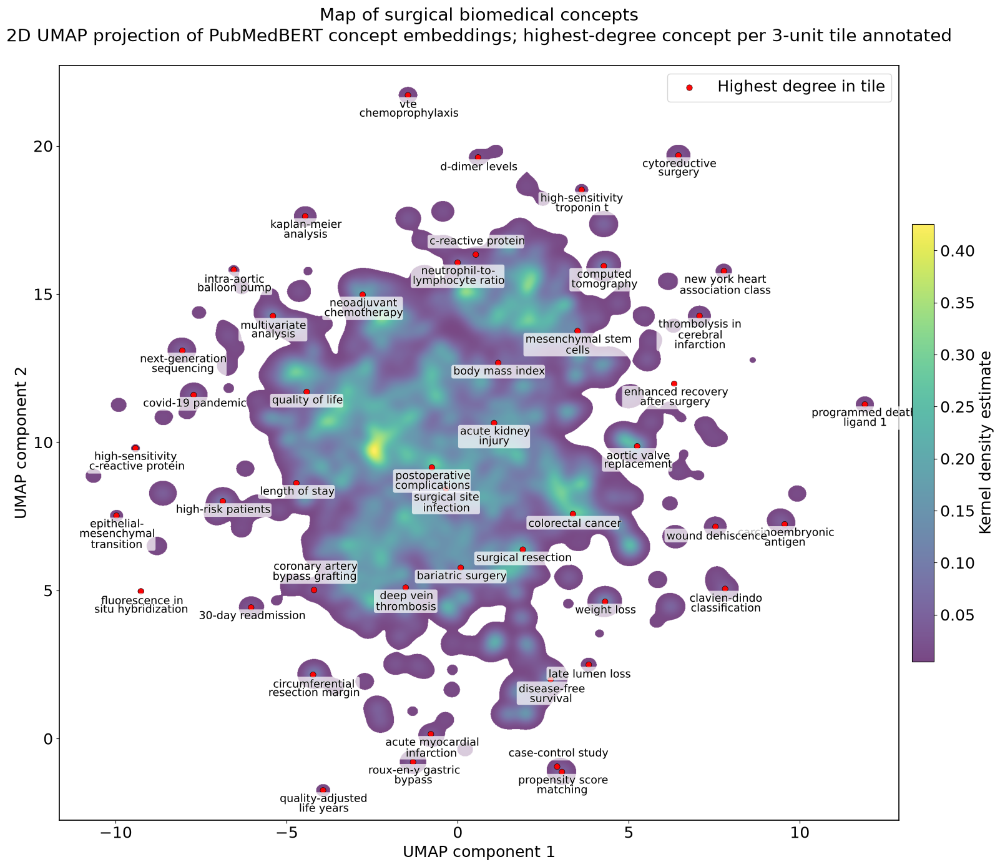

landmarks plotted: 47
wrote: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap/umap.png


In [10]:
# Create the density background. This is a fast KDE-style approximation:
# a 2D histogram smoothed with a Gaussian kernel.
import textwrap
import matplotlib.patheffects as pe

DENSITY_BINS = 2000
DENSITY_SIGMA = 16.0
DENSITY_DISPLAY_MIN = 0.005  # density values at/below this are shown as white
PADDING = 1.0
SHOW_TILE_GRID = False

# Label controls. Set MAX_LABELS=None to annotate every occupied tile.
MAX_LABELS = None  # try 250-400 if labels are too crowded
LABEL_WRAP_WIDTH = 18
LABEL_FONT_SIZE = 12.5
TITLE_FONT_SIZE = 20
TITLE_PAD = 28
AXIS_LABEL_FONT_SIZE = 18
TICK_FONT_SIZE = 18
LEGEND_FONT_SIZE = 18
COLORBAR_LABEL = "Kernel density estimate"
COLORBAR_LABEL_FONT_SIZE = 18
COLORBAR_TICK_FONT_SIZE = 18

# Point-size controls.
ALL_POINT_SIZE_MIN = 0.0
ALL_POINT_SIZE_MAX = 0.0
LANDMARK_POINT_SIZE_MIN = 45.0
LANDMARK_POINT_SIZE_MAX = 45.0

x = umap_df["umap_x"].to_numpy()
y = umap_df["umap_y"].to_numpy()

xmin, xmax = float(x.min() - PADDING), float(x.max() + PADDING)
ymin, ymax = float(y.min() - PADDING), float(y.max() + PADDING)

H, xedges, yedges = np.histogram2d(
    x,
    y,
    bins=DENSITY_BINS,
    range=[[xmin, xmax], [ymin, ymax]],
)

try:
    from scipy.ndimage import gaussian_filter
    density = gaussian_filter(H.T, sigma=DENSITY_SIGMA)
except ImportError:
    print("scipy is not installed; using unsmoothed 2D histogram density")
    density = H.T

# Density colormap. Very low-density pixels are masked and shown as white for readability.
density_cmap = "viridis"
density_for_plot = np.ma.masked_where(density <= DENSITY_DISPLAY_MIN, density)
density_cmap_obj = plt.get_cmap(density_cmap).copy()
density_cmap_obj.set_bad("white")

plot_landmarks = tile_landmarks if MAX_LABELS is None else tile_landmarks.head(int(MAX_LABELS))

# Scale all concept points by corpus frequency, capped so ultra-common concepts do not dominate.
count_cap = float(umap_df["count"].quantile(0.99))
all_count_scaled = np.sqrt(umap_df["count"].clip(upper=count_cap) / count_cap)
all_point_sizes = ALL_POINT_SIZE_MIN + (ALL_POINT_SIZE_MAX - ALL_POINT_SIZE_MIN) * all_count_scaled

# Scale landmark points by log graph degree, because landmarks are chosen by degree.
# log1p keeps very high-degree concepts from completely dominating, while making
# size differences more visible than the previous square-root scaling.
landmark_degree = plot_landmarks["graph_degree_2025"].astype(float)
landmark_degree_log = np.log1p(landmark_degree)
if len(plot_landmarks) and float(landmark_degree_log.max()) > float(landmark_degree_log.min()):
    landmark_scaled = (
        (landmark_degree_log - landmark_degree_log.min())
        / (landmark_degree_log.max() - landmark_degree_log.min())
    )
elif len(plot_landmarks):
    landmark_scaled = np.ones(len(plot_landmarks))
else:
    landmark_scaled = np.array([])
landmark_point_sizes = LANDMARK_POINT_SIZE_MIN + (LANDMARK_POINT_SIZE_MAX - LANDMARK_POINT_SIZE_MIN) * landmark_scaled

fig, ax = plt.subplots(figsize=(16, 14))

img = ax.imshow(
    density_for_plot,
    extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
    origin="lower",
    cmap=density_cmap_obj,
    alpha=0.72,
    aspect="auto",
)

# All concepts.
ax.scatter(
    umap_df["umap_x"],
    umap_df["umap_y"],
    s=all_point_sizes,
    c="black",
    alpha=0.28,
    linewidths=0,
    label="_nolegend_",
)

# Highest-degree concept in each tile.
ax.scatter(
    plot_landmarks["umap_x"],
    plot_landmarks["umap_y"],
    s=landmark_point_sizes,
    c="#FF0000",
    edgecolors="black",
    linewidths=0.45,
    alpha=0.97,
    label="Highest degree in tile",
)

for _, row in plot_landmarks.iterrows():
    concept_label = str(row["concept"]).strip()
    label = textwrap.fill(concept_label, width=LABEL_WRAP_WIDTH)
    text_style = dict(
        fontsize=LABEL_FONT_SIZE,
        color="black",
        alpha=0.98,
        linespacing=0.9,
        bbox=dict(
            boxstyle="round,pad=0.18",
            facecolor="white",
            edgecolor="none",
            alpha=0.72,
        ),
        path_effects=[pe.withStroke(linewidth=0.8, foreground="white", alpha=0.9)],
    )
    if concept_label.lower() in {"case-control study", "c-reactive protein", "coronary artery bypass grafting"}:
        ax.annotate(
            label,
            xy=(row["umap_x"], row["umap_y"]),
            xytext=(0, 13),
            textcoords="offset pixels",
            ha="center",
            va="bottom",
            **text_style,
        )
    else:
        ax.text(
            row["umap_x"],
            row["umap_y"] - 0.13,
            label,
            ha="center",
            va="top",
            **text_style,
        )

if SHOW_TILE_GRID:
    x_start = np.floor(xmin / TILE_SIZE) * TILE_SIZE
    y_start = np.floor(ymin / TILE_SIZE) * TILE_SIZE
    for xv in np.arange(x_start, xmax + TILE_SIZE, TILE_SIZE):
        ax.axvline(xv, color="white", alpha=0.08, linewidth=0.5)
    for yv in np.arange(y_start, ymax + TILE_SIZE, TILE_SIZE):
        ax.axhline(yv, color="white", alpha=0.08, linewidth=0.5)

cbar = fig.colorbar(img, ax=ax, fraction=0.025, pad=0.015)
cbar.set_label(COLORBAR_LABEL, fontsize=COLORBAR_LABEL_FONT_SIZE)
cbar.ax.tick_params(labelsize=COLORBAR_TICK_FONT_SIZE)

ax.set_title(
    "Map of surgical biomedical concepts\n"
    f"2D UMAP projection of PubMedBERT concept embeddings; highest-degree concept per {TILE_SIZE:g}-unit tile annotated",
    fontsize=TITLE_FONT_SIZE,
    pad=TITLE_PAD,
)
ax.set_xlabel("UMAP component 1", fontsize=AXIS_LABEL_FONT_SIZE, color="black")
ax.set_ylabel("UMAP component 2", fontsize=AXIS_LABEL_FONT_SIZE, color="black")
ax.tick_params(axis="both", labelsize=TICK_FONT_SIZE, colors="black")
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("black")
    spine.set_linewidth(1.2)
ax.legend(loc="upper right", frameon=True, fontsize=LEGEND_FONT_SIZE)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymin, ymax)
fig.tight_layout()
fig.savefig(PAPER_STYLE_PNG_PATH, dpi=500)
plt.show()

print("landmarks plotted:", len(plot_landmarks))
print("wrote:", PAPER_STYLE_PNG_PATH)


## Interactive paper-style heatmap UMAP

This cell creates an interactive HTML version of the paper-style map:

- kernel-density heatmap background;
- all concepts as hoverable points;
- highest-degree concept per `TILE_SIZE`-unit tile as highlighted labeled landmarks.

The HTML can be opened in a browser and shared independently of the notebook.


In [11]:
PAPER_STYLE_INTERACTIVE_HTML_PATH = OUTPUT_DIR / "umap_interactive.html"

# Cleaner interactive version:
# - heatmap carries the visual emphasis;
# - all concepts are hoverable and sized by corpus frequency;
# - highest-degree-in-tile concepts are one combined markers+text trace;
# - only the top N tile landmarks get visible text, but one legend click hides/shows
#   all tile-landmark markers and the visible labels together.
INTERACTIVE_DENSITY_STEP = 2
INTERACTIVE_MAX_BACKGROUND_POINTS = None  # set to e.g. 50000 if browser performance is poor
INTERACTIVE_MAX_LABELS = 80               # visible text labels; hover still works for all tile landmarks
INTERACTIVE_LABEL_WRAP_WIDTH = 20
INTERACTIVE_LABEL_FONT_SIZE = 11
INTERACTIVE_BACKGROUND_MARKER_SIZE_MIN = 2.0
INTERACTIVE_BACKGROUND_MARKER_SIZE_MAX = 2.0
INTERACTIVE_LANDMARK_MARKER_SIZE_MIN = 10
INTERACTIVE_LANDMARK_MARKER_SIZE_MAX =10.0

In [12]:


# Heatmap cell centers.
x_centers = (xedges[:-1] + xedges[1:]) / 2
y_centers = (yedges[:-1] + yedges[1:]) / 2

heatmap_z = density[::INTERACTIVE_DENSITY_STEP, ::INTERACTIVE_DENSITY_STEP]
# Plotly renders NaN heatmap cells as transparent gaps; with a white plot
# background, density values at/below DENSITY_DISPLAY_MIN therefore appear white.
heatmap_z_for_plot = np.where(heatmap_z <= DENSITY_DISPLAY_MIN, np.nan, heatmap_z)
heatmap_x = x_centers[::INTERACTIVE_DENSITY_STEP]
heatmap_y = y_centers[::INTERACTIVE_DENSITY_STEP]

if INTERACTIVE_MAX_BACKGROUND_POINTS is None:
    bg_df = umap_df.copy()
else:
    bg_df = umap_df.sort_values("count", ascending=False).head(int(INTERACTIVE_MAX_BACKGROUND_POINTS)).copy()

# Scale normal concept points by corpus frequency, matching the static plot.
# Counts are capped at the 99th percentile so very common concepts do not dominate.
bg_count_cap = float(bg_df["count"].quantile(0.99))
if bg_count_cap > 0:
    bg_count_scaled = np.sqrt(bg_df["count"].clip(upper=bg_count_cap) / bg_count_cap)
else:
    bg_count_scaled = np.zeros(len(bg_df))
bg_marker_sizes = INTERACTIVE_BACKGROUND_MARKER_SIZE_MIN + (
    INTERACTIVE_BACKGROUND_MARKER_SIZE_MAX - INTERACTIVE_BACKGROUND_MARKER_SIZE_MIN
) * bg_count_scaled

interactive_landmarks = plot_landmarks.copy()
interactive_landmarks["wrapped_label"] = interactive_landmarks["concept"].astype(str).map(
    lambda s: "<br>".join(textwrap.wrap(s, width=INTERACTIVE_LABEL_WRAP_WIDTH))
)

# Use log-degree scaling for tile-landmark marker size.
interactive_degree_log = np.log1p(interactive_landmarks["graph_degree_2025"].astype(float))
if len(interactive_landmarks) and float(interactive_degree_log.max()) > float(interactive_degree_log.min()):
    interactive_landmark_scaled = (
        (interactive_degree_log - interactive_degree_log.min())
        / (interactive_degree_log.max() - interactive_degree_log.min())
    )
elif len(interactive_landmarks):
    interactive_landmark_scaled = np.ones(len(interactive_landmarks))
else:
    interactive_landmark_scaled = np.array([])
interactive_landmarks["marker_size"] = INTERACTIVE_LANDMARK_MARKER_SIZE_MIN + (
    INTERACTIVE_LANDMARK_MARKER_SIZE_MAX - INTERACTIVE_LANDMARK_MARKER_SIZE_MIN
) * interactive_landmark_scaled

# The visible text labels are the highest-degree concepts among the per-tile landmarks.
# All tile landmarks remain visible as markers in the same trace.
label_ids = set(
    interactive_landmarks
    .sort_values("graph_degree_2025", ascending=False)
    .head(INTERACTIVE_MAX_LABELS)["id"]
)
interactive_landmarks["display_label"] = np.where(
    interactive_landmarks["id"].isin(label_ids),
    interactive_landmarks["wrapped_label"],
    "",
)

fig = go.Figure()

# 1) Density heatmap background.
fig.add_trace(go.Heatmap(
    x=heatmap_x,
    y=heatmap_y,
    z=heatmap_z_for_plot,
    colorscale="viridis_r",
    reversescale=True,
    opacity=0.78,
    colorbar=dict(
        title=dict(
            text=COLORBAR_LABEL,
            font=dict(size=COLORBAR_LABEL_FONT_SIZE),
            side="right",
        ),
        tickfont=dict(size=COLORBAR_TICK_FONT_SIZE),
        x=1.035,
        xanchor="left",
        y=0.5,
        yanchor="middle",
        len=0.78,
        thickness=18,
    ),
    name="Kernel density estimate",
    hoverongaps=False,
    hovertemplate="UMAP 1=%{x:.2f}<br>UMAP 2=%{y:.2f}<br>KDE=%{z:.3g}<extra></extra>",
))

# 2) All concepts.
# Use a small legend-only trace first, so the legend dot is readable while the
# actual background points keep their data-driven marker sizes.
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode="markers",
    name="All concepts",
    legendgroup="all_concepts",
    hoverinfo="skip",
    marker=dict(
        size=15,
        color="rgba(0,0,0,0.42)",
        line=dict(width=0),
    ),
))

# Hoverable concept points, sized by concept frequency.
fig.add_trace(go.Scattergl(
    x=bg_df["umap_x"],
    y=bg_df["umap_y"],
    mode="markers",
    name="All concepts",
    legendgroup="all_concepts",
    showlegend=False,
    text=bg_df["concept"],
    customdata=np.stack([
        bg_df["id"].to_numpy(),
        bg_df["count"].to_numpy(),
        bg_df["graph_degree_2025"].to_numpy(),
    ], axis=1),
    hovertemplate=(
        "<b>%{text}</b><br>"
        "id=%{customdata[0]}<br>"
        "count=%{customdata[1]}<br>"
        "graph degree 2025=%{customdata[2]}"
        "<extra></extra>"
    ),
    marker=dict(
        size=bg_marker_sizes,
        color="rgba(0,0,0,0.28)",
        line=dict(width=0),
    ),
))

# 3) Highest-degree-in-tile landmark markers.
# Labels are added as a separate final text trace below, so text stays on top
# of all points in the interactive plot. Both traces share one legend group.
landmark_customdata = np.stack([
    interactive_landmarks["concept"].to_numpy(),
    interactive_landmarks["count"].to_numpy(),
    interactive_landmarks["graph_degree_2025"].to_numpy(),
    interactive_landmarks["tile_x"].to_numpy(),
    interactive_landmarks["tile_y"].to_numpy(),
], axis=1)

fig.add_trace(go.Scatter(
    x=interactive_landmarks["umap_x"],
    y=interactive_landmarks["umap_y"],
    mode="markers",
    name="Highest degree in tile",
    legendgroup="tile_landmarks",
    customdata=landmark_customdata,
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "count=%{customdata[1]}<br>"
        "graph degree 2025=%{customdata[2]}<br>"
        "tile=(%{customdata[3]}, %{customdata[4]})"
        "<extra></extra>"
    ),
    marker=dict(
        size=interactive_landmarks["marker_size"],
        symbol="circle",
        color="rgba(255,0,0,0.92)",
        line=dict(color="rgba(0,0,0,0.85)", width=0.85),
    ),
))

# 4) Landmark text labels, drawn as annotations after all traces.
# Plotly scatter text has no real background box; annotations do.
# These labels therefore stay above all points and have a translucent white backing.
visible_label_rows = interactive_landmarks[interactive_landmarks["display_label"] != ""]
for _, row in visible_label_rows.iterrows():
    fig.add_annotation(
        x=float(row["umap_x"]),
        y=float(row["umap_y"]),
        text=str(row["display_label"]),
        showarrow=False,
        visible=True,
        xanchor="center",
        yanchor="top",
        xshift=0,
        yshift=-12,
        align="center",
        font=dict(
            size=INTERACTIVE_LABEL_FONT_SIZE,
            color="black",
        ),
        bgcolor="rgba(255,255,255,0.74)",
        bordercolor="rgba(0,0,0,0.28)",
        borderwidth=0.5,
        borderpad=2,
        opacity=0.98,
    )

fig.update_layout(
    title=dict(
        text=(
            "Map of surgical biomedical concepts<br>"
            "<sup>2D UMAP projection of PubMedBERT concept embeddings; "
            f"highest-degree concept per {TILE_SIZE:g}-unit tile highlighted</sup>"
        ),
        font=dict(size=TITLE_FONT_SIZE),
        x=0.5,
        xanchor="center",
        y=0.965,
        yanchor="top",
    ),
    xaxis=dict(
        title=dict(text="UMAP component 1", font=dict(size=AXIS_LABEL_FONT_SIZE, color="black")),
        tickfont=dict(size=TICK_FONT_SIZE, color="black"),
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1.5,
        ticks="outside",
        tickcolor="black",
        mirror=True,
    ),
    yaxis=dict(
        title=dict(text="UMAP component 2", font=dict(size=AXIS_LABEL_FONT_SIZE, color="black")),
        tickfont=dict(size=TICK_FONT_SIZE, color="black"),
        zeroline=False,
        showline=True,
        linecolor="black",
        linewidth=1.5,
        ticks="outside",
        tickcolor="black",
        mirror=True,
    ),
    legend=dict(
        x=0.985,
        y=0.985,
        xanchor="right",
        yanchor="top",
        font=dict(size=LEGEND_FONT_SIZE),
        bgcolor="rgba(255,255,255,0.82)",
        bordercolor="rgba(0,0,0,0.25)",
        borderwidth=1,
        groupclick="togglegroup",
        itemsizing="constant",
    ),
    width=1300,
    height=1100,
    margin=dict(l=75, r=145, t=110, b=75),
    plot_bgcolor="white",
    paper_bgcolor="white",
)

# Write HTML with a custom legend hook.
# Plotly annotations have the white background boxes we want, but annotations
# are not traces, so they do not automatically follow legend clicks. The
# post_script runs after Plotly creates the figure and makes the landmark label
# annotations disappear/reappear together with the landmark marker trace.
landmark_toggle_js = r"""
var gd = document.getElementById('{plot_id}');
var landmarkTraceIndex = -1;
for (var i = 0; i < gd.data.length; i++) {
  if (gd.data[i].name === 'Highest degree in tile') {
    landmarkTraceIndex = i;
    break;
  }
}

function setLandmarkLabelVisibility(visible) {
  var annotations = gd.layout.annotations || [];
  var update = {};
  for (var i = 0; i < annotations.length; i++) {
    update['annotations[' + i + '].visible'] = visible;
  }
  Plotly.relayout(gd, update);
}

if (landmarkTraceIndex >= 0) {
  gd.on('plotly_legendclick', function(eventData) {
    if (eventData.curveNumber !== landmarkTraceIndex) return;

    var currentVisible = gd.data[landmarkTraceIndex].visible;
    var nextVisible = (currentVisible === true || currentVisible === undefined) ? 'legendonly' : true;

    Plotly.restyle(gd, {'visible': nextVisible}, [landmarkTraceIndex]);
    setLandmarkLabelVisibility(nextVisible === true);

    // Prevent Plotly's default legend action from running a second toggle.
    return false;
  });
}
"""

fig.write_html(
    PAPER_STYLE_INTERACTIVE_HTML_PATH,
    full_html=True,
    include_plotlyjs="cdn",
    post_script=landmark_toggle_js,
)

print("wrote:", PAPER_STYLE_INTERACTIVE_HTML_PATH)
print("tile landmark markers:", len(interactive_landmarks))
print("visible landmark labels:", int((interactive_landmarks["display_label"] != "").sum()))
print("all-concept marker size min/median/max:", round(float(np.min(bg_marker_sizes)), 2), round(float(np.median(bg_marker_sizes)), 2), round(float(np.max(bg_marker_sizes)), 2))

# The custom legend-label toggle is in the saved HTML file.
# fig.show() below displays the Plotly figure inline, but may not include that
# custom HTML hook depending on the notebook renderer.
fig.show()


wrote: /Users/maximillian/Polybox/Projects/biomed-hypothesis-ml/visualization/umap/umap_interactive.html
tile landmark markers: 47
visible landmark labels: 47
all-concept marker size min/median/max: 2.0 2.0 2.0
